# statistical comparisons

Notebook to run post-hoc pairwise statistical comparisons between methods on the ground-truth and black-box regression problems.

In [49]:
from scipy.stats import wilcoxon 
import pandas as pd
import itertools as it
import os
import seaborn as sns
sns.set(font_scale=1, style='white')

import pdb
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import LogNorm

rdir  = '../../results/black-box-tuning/'
figdir = f'../figs/black-box-tuning/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

print('figdir:',figdir)
def save(h=None, name='tmp', figdir=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    if figdir is not None:
        print('saving',figdir+'/'+name+'.pdf')

        if not os.path.exists(figdir):
            os.makedirs(figdir)

        plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')
        plt.savefig(figdir+'/'+name+'.png', bbox_inches='tight')
    else: # just show it
        print('plot was not saved because no figdir was specified')
        plt.show()

figdir: ../figs/black-box-tuning/


In [50]:
def pairwise_pval(df, metric, alg1, alg2):
    df = df.loc[df.algorithm.isin([alg1, alg2]),:].copy()
    x = df.loc[df.algorithm==alg1, metric].values 
    y = df.loc[df.algorithm==alg2, metric].values 

    eff_size = np.abs(np.nanmedian(x)/np.nanmedian(y))
    if metric.endswith('norm'):
        rmetric = metric.replace('norm','rank')
    else:
        rmetric = metric+'_rank'
    if rmetric not in df.columns:
        rmetric = metric
        
    x_rank = df.loc[df.algorithm==alg1, rmetric].values 
    y_rank = df.loc[df.algorithm==alg2, rmetric].values 
#     pdb.set_trace()
    if len(x) != len(y):
        print(alg1, len(x))
        print(alg2, len(y))
    assert len(x) == len(y)

#     w, p = mannwhitneyu(x, y)

    # zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.
    if all(y==0) and all(x==0):
        return 1, 1

    if all(x-y==0):
        print('x-y is zero for all samples')
        return 1, 1
    
    w, p = wilcoxon(x, y)
    return p, eff_size

#     return pstr, eff_size_str

def signif(pval, alpha, eff):
    pstr = '{:1.2g}'.format(pval)
    eff_size_str = '{:1.1f}X'.format(eff)
    if pval == '-': return pval
    if float(pval) < alpha:
        return 'textbf{'+pstr+'}', 'textbf{'+eff_size_str+'}'
#         return pval+'*'
    else:
        return pstr, eff_size_str
    
def bin_pval(x, c_alpha):
    for stars,level in zip([4,3,2,1],[1e-6, 1e-4, 1e-1, 1]):
        if x < level*c_alpha: 
            return stars #level #*c_alpha
    return 0

alpha = 0.05
def get_pval_df(df, metric, all_algs):
    df = df.copy()
    n=0
    pvals = []
    for alg1, alg2 in it.combinations(all_algs, 2):
        pval, eff_size = pairwise_pval(df, metric, alg1, alg2)
        pvals.append(dict(
            alg1 = alg1,
            alg2 = alg2,
            eff_size = eff_size,
            pval = pval
        ))
        n += 1

    # Avoid alpha inflation when performing multiple comparisons.
    c_alpha = alpha/n

    print('n:',n,'c_alpha:',c_alpha) 
    df_pvals = pd.DataFrame.from_records(pvals)
    # df_pvals['pval_thresh'] = pd.cut(x=df_pvals['pval'], bins = [0, c_alpha, 1])
    df_pvals['pval_thresh'] = df_pvals['pval'].apply(lambda x: bin_pval(x, c_alpha))

    # significance
    df_pvals.loc[:,'pval_bold'] = df_pvals.apply(lambda x: signif(x['pval'], 
                                                                      c_alpha,
                                                                      x['eff_size'])[0],
                                                     axis=1
                                                    )
    df_pvals.loc[:,'eff_size_bold'] = df_pvals.apply(lambda x: signif(x['pval'], 
                                                                      c_alpha,
                                                                      x['eff_size'])[1],
                                                     axis=1
                                                    )
    return df_pvals, c_alpha

In [51]:
def pval_heatmap(df, metric, problem, algs):
    df = df.copy()
    n = 0 
    pvals = []

    df_pvals, c_alpha = get_pval_df(df, metric, algs)
    
    #                                                  pd.cut(x=df_pvals['pval'], bins = [0, c_alpha, 1])
    tbl = df_pvals.set_index(['alg1','alg2'])['pval_thresh'].unstack().transpose() #.fillna('-')

    mask = np.zeros_like(tbl, dtype=bool)
    mask[np.triu_indices_from(mask,k=1)] = True

    display(tbl)

    h = plt.figure(figsize=(10,10))

    cmap = sns.color_palette('flare',n_colors=5)
    cmap[0] = [.9, .9, .9]
    ax = sns.heatmap(tbl, 
                linewidth=0.25,
                mask=mask,
                square=True,
                cbar_kws=dict(
                              ticks = [0.4, 1.2, 2.0, 2.8, 3.6],
                              shrink=0.6,
                ),
                cmap=cmap
               )

    cax = h.axes[-1]
    cbar_labels = [
                   'no significance',
                   '$p<\\alpha$',
                   '$p<$1e-1$\cdot \\alpha$',
                   '$p<$1e-2$\cdot \\alpha$',
                   '$p<$1e-3$\cdot \\alpha$',
                  ]
    cax.set_yticklabels(cbar_labels)
    nice_metric = metric.replace('%','pct').replace('_',' ').replace('R2','$$R^2$$').title()
    plt.title(('Wilcoxon signed-rank test, '
              +nice_metric
              +', $\\alpha =$ {:1.1e}').format(c_alpha)
             )
    plt.xlabel('')
    plt.ylabel('')
    savename = ('Pairwise comparison of '
              +nice_metric
              +' on '
              +problem).replace(' ','_')
    save(h, savename, figdir)

# Black-Box datasets

## load data and fill nan results

In [52]:
df_results = pd.read_feather(rdir+'/results.feather')
df_results

df_results = df_results[~df_results['algorithm'].isin(['Genetic Engine rs', 'Genetic Engine hc', 'Genetic Engine 1p1'])]

df_results = df_results.replace({'Genetic Engine':'G. Engine'})


# ##############################
# # Creating summary report file
# ##############################

# rankings per trial per dataset
for col in [c for c in df_results.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_results[col+'_rank_per_trial']=df_results.groupby(
                        ['dataset','random_state'], group_keys=False)[col].apply(lambda x: 
                                                                round(x,3).rank(
                                                                ascending=ascending).astype(int))
    
# also including random state as group key
df_sum = df_results.groupby(['algorithm','dataset','random_state'],as_index=False, group_keys=False).median()
df_sum['rmse_test'] = df_sum['mse_test'].apply(np.sqrt)
df_sum['log_mse_test'] = df_sum['mse_test'].apply(lambda x: np.log(1+x))
df_sum['*algorithm*'] = df_sum.apply(
    lambda row: ('*' if row['symbolic_alg'] else "")+row['algorithm'], axis=1 )
    
# rankings and normalized scores per dataset
for col in [c for c in df_sum.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_sum[col+'_rank']=df_sum.groupby(['dataset', 'random_state'], group_keys=False)[col].apply(lambda x: 
                                                                        round(x,3).rank(ascending=ascending)
                                                                  )
    df_sum[col+'_norm'] = df_sum.groupby('dataset', group_keys=False)[col].apply(lambda x: (x-x.min())/(x.max()-x.min()))
    
for col in ['algorithm','dataset']:
    print(df_results[col].nunique(), col+'s')

# df_sum = pd.read_csv(rdir+'/results-summary.csv.gz')

df_sum

/tmp/ipykernel_3245505/3019083668.py:22: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_sum = df_results.groupby(['algorithm','dataset','random_state'],as_index=False, group_keys=False).median()


25 algorithms
12 datasets


,algorithm,dataset,random_state,training time (s),mse_test,mae_test,r2_test,model_size,training time (hr),symbolic_alg,...,r2_test_rank,r2_test_norm,model_size_rank,model_size_norm,r2_zero_test_rank,r2_zero_test_norm,rmse_test_rank,rmse_test_norm,log_mse_test_rank,log_mse_test_norm
0,AFP,1028_SWD,769,397.805950,0.454895,0.553842,0.215156,-1.0,0.110502,1.0,...,19.0,0.930825,1.5,0.000000,19.0,0.456491,19.0,8.858024e-02,19.0,0.083078
1,AFP,1028_SWD,860,342.068418,0.429076,0.533318,0.368129,-1.0,0.095019,1.0,...,16.0,0.972133,1.5,0.000000,16.0,0.781049,16.0,6.970227e-02,16.0,0.064949
2,AFP,1028_SWD,1685,94.710908,0.417186,0.508546,0.341296,35.0,0.026309,1.0,...,10.0,0.964887,15.5,0.002949,10.0,0.724118,9.5,6.081850e-02,10.5,0.056490
3,AFP,1028_SWD,2433,80.395628,0.393458,0.519582,0.430708,46.0,0.022332,1.0,...,2.0,0.989032,16.0,0.003851,2.0,0.913822,2.0,4.270181e-02,2.0,0.039395
4,AFP,1028_SWD,4426,76.987072,0.436969,0.543746,0.328336,32.0,0.021385,1.0,...,9.0,0.961387,10.5,0.002704,9.0,0.696621,8.5,7.553197e-02,9.5,0.070525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8868,uDSR,678_visualizing_environmental,29802,481.499844,10.417739,2.435416,-0.036419,17.0,0.133750,1.0,...,15.0,1.000000,15.5,0.002632,20.0,0.000000,15.0,6.178173e-15,15.0,0.011694
8869,uDSR,678_visualizing_environmental,29910,538.660823,18.003898,3.332818,-0.156090,5.0,0.149628,1.0,...,21.0,1.000000,7.5,0.000877,21.5,0.000000,21.0,1.173279e-14,21.0,0.019655
8870,uDSR,678_visualizing_environmental,30187,403.765651,11.469997,2.808724,0.116690,3.0,0.112157,1.0,...,16.0,1.000000,5.0,0.000585,16.0,0.191350,16.0,7.048393e-15,16.0,0.013071
8871,uDSR,678_visualizing_environmental,32052,664.812559,12.078815,2.794229,-0.547081,20.0,0.184670,1.0,...,17.0,1.000000,14.0,0.003071,17.0,0.000000,17.0,7.533705e-15,17.0,0.013816


In [53]:
algs = df_sum.algorithm.unique()
datasets = df_sum.dataset.unique()
random_states = df_sum.random_state.unique()

print("algorithms", len(algs))
print("datasets", len(datasets))
print("random_state", len(random_states))
print("df_sum shape", df_sum.shape)

cols = df_sum.columns
for col in [c for c in cols if 'rank' in c]:
    df_sum.loc[:,col] = df_sum[col].fillna(len(algs)+1)
for col in [c for c in cols if 'solution_rate' in c]:
    df_sum.loc[:,col] = df_sum[col].fillna(0.0)

df_sum.sample(5)

algorithms 25
datasets 12
random_state 30
df_sum shape (8873, 37)


,algorithm,dataset,random_state,training time (s),mse_test,mae_test,r2_test,model_size,training time (hr),symbolic_alg,...,r2_test_rank,r2_test_norm,model_size_rank,model_size_norm,r2_zero_test_rank,r2_zero_test_norm,rmse_test_rank,rmse_test_norm,log_mse_test_rank,log_mse_test_norm
3226,FEAT,1028_SWD,11363,166.867983,4.511846e-01,0.546569,0.321421,22.0,0.046352,1.0,...,14.0,0.959520,10.0,0.001884,14.0,0.681950,14.5,0.085901,14.0,0.080492
2430,E2E,606_fri_c2_1000_10,27495,20.780245,3.390122e-01,0.442209,0.661698,48.0,0.005772,1.0,...,20.0,0.935027,13.0,0.011076,20.0,0.674524,20.0,0.230686,20.0,0.166012
2652,EPLEX,210_cloud,5390,63.992111,1.652960e-01,0.299024,0.611247,39.0,0.017776,1.0,...,16.0,0.999996,14.5,0.004896,16.0,0.634190,16.0,0.000469,16.0,0.009317
1319,BSR,557_analcatdata_apnea1,32157,129.221698,6.862928e+06,1291.394873,0.180385,23.0,0.035895,1.0,...,19.0,0.894779,14.0,0.001744,19.0,0.185530,19.0,0.243102,19.0,0.585717
1045,AFP_FE,650_fri_c0_500_50,29802,28.611109,4.019198e-01,0.510396,0.620157,25.0,0.007948,1.0,...,18.0,0.847761,10.0,0.003040,18.0,0.642024,18.0,0.349449,18.0,0.272785


In [54]:
# if a result is missing, assign it the worst ranking
# cols = df_sum.columns
filler_frame = {
    'r2_test_rank' : len(algs)+1,
    'model_size_rank' : len(algs)+1,
    'r2_test' : np.nanmin(df_sum['r2_test']),
    "model_size" : np.nanmax(df_sum['model_size']),
    "rmse_test" : np.nanmax(df_sum['rmse_test']),
    "mse_test" : np.nanmax(df_sum['mse_test']),
}

print(filler_frame)

fill_frames = []
j = 0
for dataset in datasets:
    for alg in algs:
        for rs in random_states:
            df = df_sum.loc[(df_sum.dataset == dataset) & (df_sum.random_state == rs)]
            if alg not in df.algorithm.unique():
                # print('filling',alg,'missing for',dataset,'...',end=' ')
                new_fill = filler_frame.copy()
                new_fill.update({
                                'algorithm':alg,
                                'dataset':dataset,
                                'random_state':rs,
                                })
                
                # print(new_fill)
                fill_frames.append(new_fill)
                j += 1

print("Filled", j, "individual runs")

df_fill = pd.DataFrame.from_records(fill_frames, columns=fill_frames[0].keys()) 
df_sum_filled = df_sum.append(df_fill)


df_sum_filled.sample(5)

{'r2_test_rank': 26, 'model_size_rank': 26, 'r2_test': -8.87636148610185e+91, 'model_size': 14799.0, 'rmse_test': 3.5292623328357457e+47, 'mse_test': 1.2455692613973209e+95}
Filled 127 individual runs


/tmp/ipykernel_3245505/1353352370.py:36: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_sum_filled = df_sum.append(df_fill)


,algorithm,dataset,random_state,training time (s),mse_test,mae_test,r2_test,model_size,training time (hr),symbolic_alg,...,r2_test_rank,r2_test_norm,model_size_rank,model_size_norm,r2_zero_test_rank,r2_zero_test_norm,rmse_test_rank,rmse_test_norm,log_mse_test_rank,log_mse_test_norm
5058,ITEA,1089_USCrime,15795,4.960618,131.242035,9.254699,0.931754,12.0,0.001378,1.0,...,1.0,1.00000,8.5,0.004906,1.0,0.970371,1.0,8.760646e-48,1.0,0.002899
4579,GP-GOMEA,606_fri_c2_1000_10,16023,644.995958,0.081107,0.227863,0.923193,70.0,0.179166,1.0,...,11.0,0.98824,21.0,0.016049,11.0,0.941087,11.0,7.725242e-02,11.0,0.036321
2325,E2E,522_pm10,860,91.664140,0.986790,0.764045,-0.002041,1.0,0.025462,1.0,...,22.0,1.00000,3.0,0.000245,23.5,0.000000,22.0,3.152084e-07,22.0,0.012434
3986,G. Engine,1089_USCrime,26967,3600.033039,467.178393,17.970733,0.626363,7.0,1.000009,1.0,...,16.0,1.00000,3.0,0.003019,16.0,0.652323,16.0,3.754348e-47,16.0,0.008788
2159,Brush,678_visualizing_environmental,32157,175.759421,10.536527,2.847115,-0.090227,13.0,0.048822,1.0,...,14.0,1.00000,11.0,0.002047,19.0,0.000000,14.0,6.278546e-15,14.0,0.011855


## generate tables

In [55]:
# # baseline significance threshold; adjusted for no. of comparisons below
# alpha = 0.05
# BB_pvals = {}

# for metric in ['r2_test','model_size']:
#     pvals = []

#     n = 0 
#     df_pvals, c_alpha = get_pval_df(df_sum_filled, metric, algs) 
#     pval_tbl = df_pvals.set_index(['alg1','alg2'])['pval'].unstack() 
#     BB_pvals[metric] = pval_tbl.copy() 
#     pval_tbl = pval_tbl.fillna('-')
#     display(pval_tbl)

n: 300 c_alpha: 0.0001666666666666667


alg1,AFP,AFP_EHC,AFP_FE,BSR,Bingo,Brush,E2E,EPLEX,EQL,FEAT,...,ITEA,NeSymRes,Operon,PS-Tree,PYSR,QLattice,Rils-Rols,TIR,TPSR,gplearn
alg2,,,,,,,,,,,,,,,,,,,,,
AFP_EHC,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFP_FE,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BSR,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bingo,1.0,0.0,0.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brush,3.0,3.0,3.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2E,4.0,4.0,4.0,0.0,4.0,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPLEX,0.0,0.0,0.0,4.0,0.0,3.0,4.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EQL,4.0,4.0,4.0,4.0,4.0,0.0,4.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FEAT,0.0,1.0,0.0,4.0,0.0,2.0,4.0,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


saving ../figs/black-box-tuning//Pairwise_comparison_of_R2_Test_on_black-box_problems.pdf
n: 300 c_alpha: 0.0001666666666666667


alg1,AFP,AFP_EHC,AFP_FE,BSR,Bingo,Brush,E2E,EPLEX,EQL,FEAT,...,ITEA,NeSymRes,Operon,PS-Tree,PYSR,QLattice,Rils-Rols,TIR,TPSR,gplearn
alg2,,,,,,,,,,,,,,,,,,,,,
AFP_EHC,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFP_FE,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BSR,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bingo,1.0,2.0,0.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brush,3.0,4.0,1.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2E,4.0,4.0,4.0,0.0,4.0,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPLEX,0.0,0.0,0.0,4.0,0.0,4.0,3.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EQL,4.0,4.0,4.0,4.0,4.0,2.0,4.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FEAT,0.0,0.0,0.0,4.0,0.0,1.0,4.0,0.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


saving ../figs/black-box-tuning//Pairwise_comparison_of_Mse_Test_on_black-box_problems.pdf
n: 300 c_alpha: 0.0001666666666666667


alg1,AFP,AFP_EHC,AFP_FE,BSR,Bingo,Brush,E2E,EPLEX,EQL,FEAT,...,ITEA,NeSymRes,Operon,PS-Tree,PYSR,QLattice,Rils-Rols,TIR,TPSR,gplearn
alg2,,,,,,,,,,,,,,,,,,,,,
AFP_EHC,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFP_FE,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BSR,4.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Bingo,4.0,4.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brush,4.0,4.0,4.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2E,4.0,4.0,4.0,4.0,4.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EPLEX,4.0,4.0,4.0,4.0,4.0,2.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EQL,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FEAT,4.0,4.0,4.0,4.0,4.0,0.0,0.0,0.0,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


saving ../figs/black-box-tuning//Pairwise_comparison_of_Model_Size_on_black-box_problems.pdf


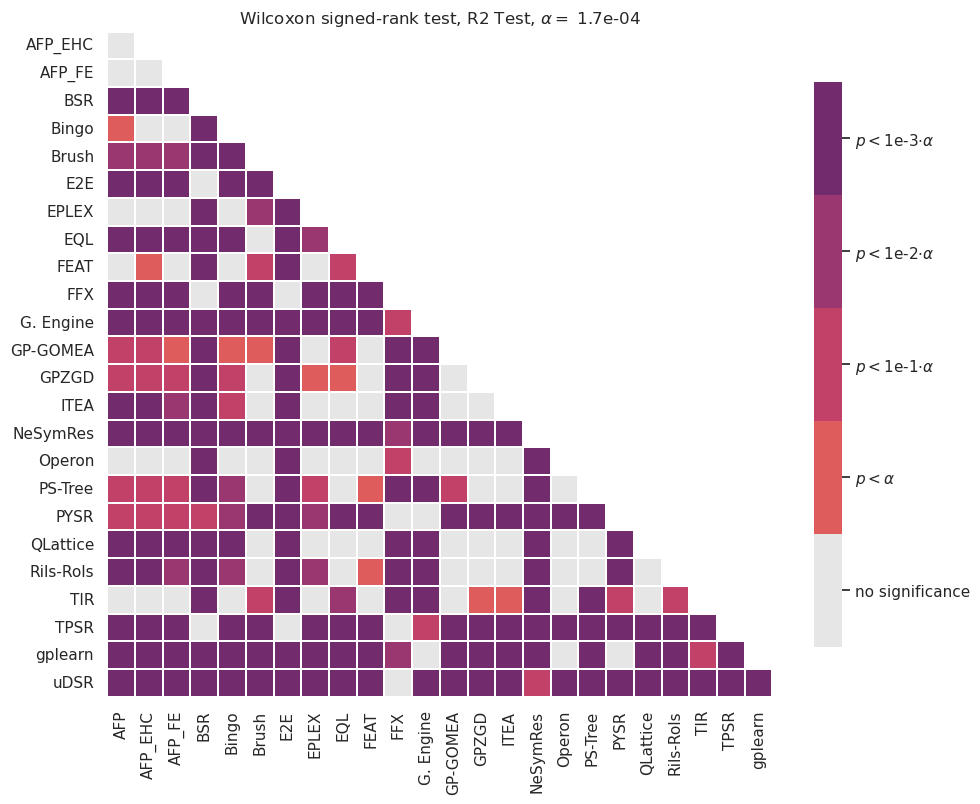

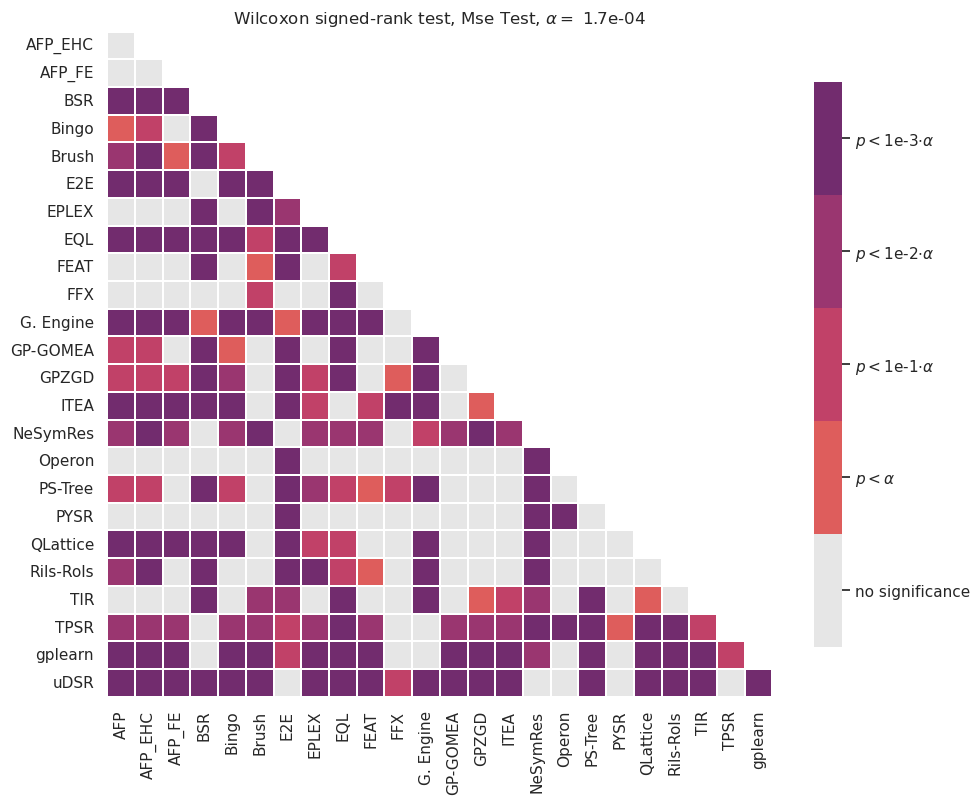

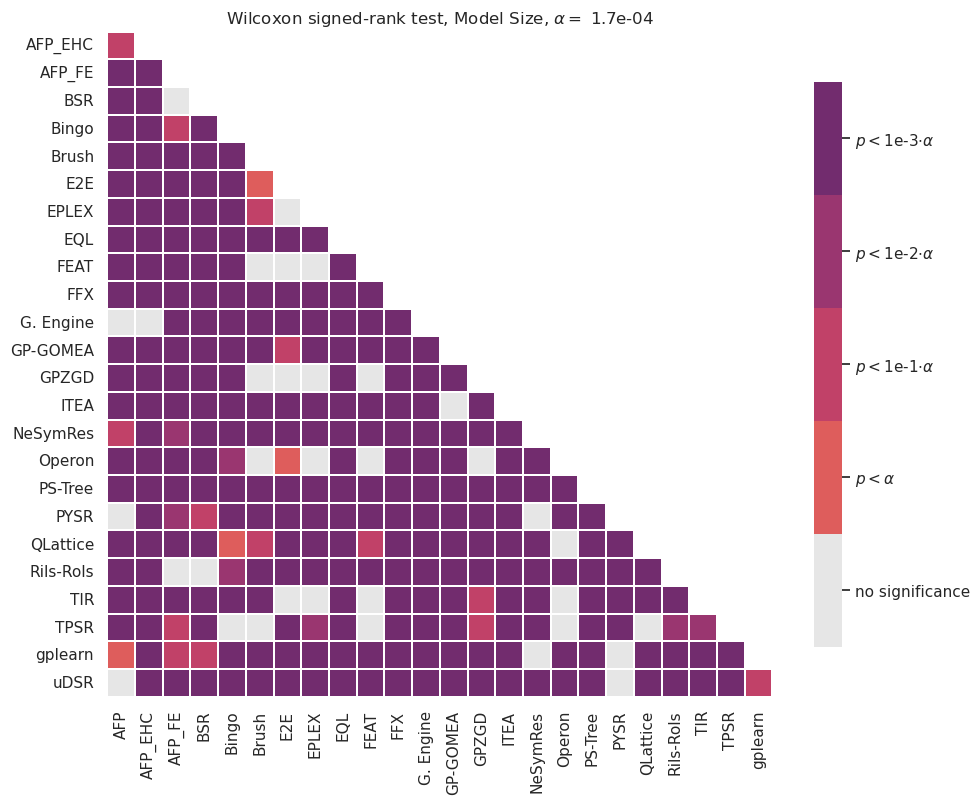

In [56]:
for metric in ['r2_test', 'mse_test', 'model_size']: #, 'model_size']:
    name = 'black-box_problems'
    pval_heatmap(df_sum_filled, metric, name, algs)

In [ ]:

for metric in ['r2_test', 'mse_test']:
    tbl = df.groupby(["dataset","algorithm"])[criteria].apply(args.agg).unstack()

    # ss.friedmanchisquare(*dict_data.values())


algorithm
EQL           7.480556
PS-Tree       8.452778
Operon        8.675000
Brush         8.675000
ITEA          8.991667
GPZGD         9.266667
Rils-Rols     9.286111
QLattice      9.466667
GP-GOMEA     10.247222
FEAT         10.719444
TIR          10.877778
EPLEX        11.519444
Bingo        11.694444
AFP_FE       11.797222
AFP          12.441667
AFP_EHC      12.741667
FFX          15.013889
PYSR         15.254167
G. Engine    15.994444
gplearn      16.075000
BSR          18.536111
TPSR         18.561111
E2E          19.979167
NeSymRes     21.100000
uDSR         22.152778
Name: r2_test, dtype: float64

FriedmanchisquareResult(statistic=114.09962177062634, pvalue=1.0767447064296161e-13)
saving ../figs/black-box-tuning//critical_differences_r2_test.pdf


algorithm
EQL           7.480556
PS-Tree       8.452778
Operon        8.675000
Brush         8.675000
ITEA          8.990278
GPZGD         9.266667
Rils-Rols     9.287500
QLattice      9.466667
GP-GOMEA     10.247222
FEAT         10.719444
TIR          10.877778
EPLEX        11.519444
Bingo        11.694444
AFP_FE       11.797222
AFP          12.441667
AFP_EHC      12.741667
FFX          15.013889
PYSR         15.254167
G. Engine    15.994444
gplearn      16.075000
BSR          18.536111
TPSR         18.561111
E2E          19.979167
NeSymRes     21.100000
uDSR         22.152778
Name: mse_test, dtype: float64

FriedmanchisquareResult(statistic=110.15475350984036, pvalue=5.298849257112924e-13)
saving ../figs/black-box-tuning//critical_differences_mse_test.pdf


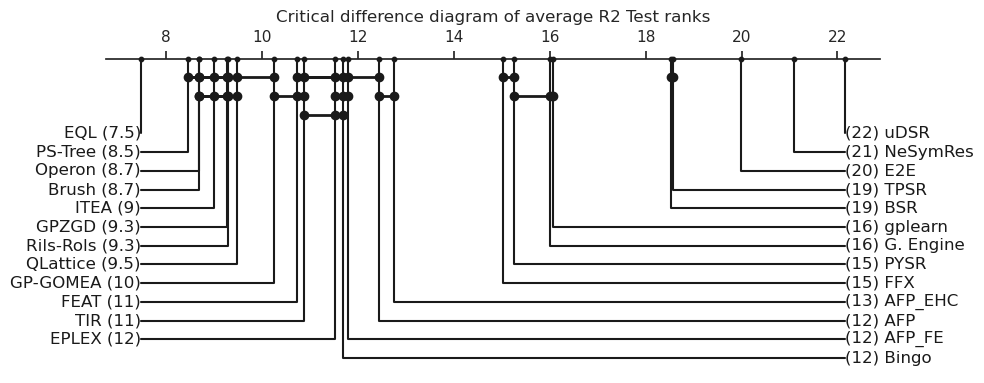

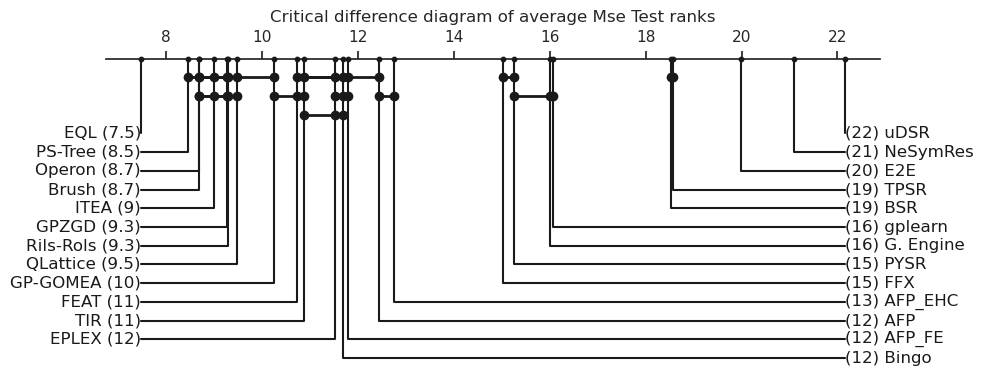

In [64]:
import scikit_posthocs as sp
import scipy.stats as ss

for metric in ['r2_test', 'mse_test']:# , 'model_size']:
    # Create a single column for blocks
    df_sum_filled_aux = df_sum_filled.copy()
    df_sum_filled_aux["block"] = df_sum_filled_aux["dataset"].astype(str) + "_" + df_sum_filled_aux["random_state"].astype(str)

    avg_rank = df_sum_filled_aux.groupby('block')[metric].rank(
        ascending=True if metric in ['model_size', 'mse_test'] else False, 
        pct=False).groupby(df_sum_filled_aux.algorithm).mean()
    display(avg_rank.sort_values())

    tbl = df_sum_filled_aux.groupby(["dataset", 'algorithm'])[metric].mean().unstack()
    print(ss.friedmanchisquare(*tbl.values.T))

    # Posthoc test with merged block column
    test_results = sp.posthoc_conover_friedman(
        df_sum_filled_aux[['block', 'algorithm', metric]],
        melted=True,
        block_col="block",
        block_id_col="block",
        group_col="algorithm",
        y_col=metric,
    )

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    plt.title('Critical difference diagram of average score ranks')
    sp.critical_difference_diagram(
        avg_rank, test_results, color_palette=['k']*len(algs), ax=ax,
        crossbar_props={'color': 'k', 'marker': 'o'},
        marker_props={'marker': 'o', 's': 10, 'color': 'k', 'edgecolor': 'k'},
        # elbow_props={'color': 'gray'},
    )

    nice_metric = metric.replace('%','pct').replace('_',' ').replace('R2','$$R^2$$').title()
    ax.set_title(f'Critical difference diagram of average {nice_metric} ranks')

    save(fig, f"critical_differences_{metric}", figdir)